In [6]:
import pandas as pd
import geopandas as gpd
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.sequential as SEQUENTIAL
from nomad.stop_detection.density_based import seqscan_labels
from nomad.stop_detection.dbscan import ta_dbscan_labels
from nomad.stop_detection.density_based import seqscan_labels_per_user
from nomad.stop_detection.lachesis import lachesis_labels_per_user

import nomad.visit_attribution.visit_attribution as visits

from nomad.contact_estimation import compute_stop_detection_metrics
import warnings
warnings.filterwarnings('ignore', message='Input is timezone-aware; assuming UTC')

In [7]:

def user_maxima_summary(data, algo_prefix, beta_ping, ha, metric="recall", param='delta_roam'):
    data = data.loc[data.algorithm.str.startswith(algo_prefix)]
    stats_by_user = (
        data.loc[data.groupby("user_id")[metric].idxmax(), ["user_id", metric, param]]
        .reset_index(drop=True)
    )
    e_theta_star = stats_by_user[param].quantile(0.5, interpolation='lower')
    e_x_theta_star = stats_by_user[metric].median()
    lo, hi = stats_by_user[param].quantile([0.025, 0.975])
    in_interval = data.loc[data[param].between(lo, hi)]
    std_by_delta = in_interval.groupby(param)[metric].std()
    mean_metric_by_param = in_interval.groupby(param)[metric].mean()
    return {
        "beta_ping": beta_ping,
        "ha": ha,
        "med_optimal_param": e_theta_star,
        "med_best_metric": round(e_x_theta_star, 4),
        "95pct_param_range": f"[{lo:.1f}, {hi:.1f}]",
        "std_at_optimal_param": std_by_delta.loc[e_theta_star],
        "max_std_in_interval": std_by_delta.max(),
        "min_std_in_interval": std_by_delta.min(),
        "max_mean_performance": mean_metric_by_param.max(),
        "min_interval_performance": mean_metric_by_param.min()
    }

In [8]:
config_files = ['config_ha13_beta5.json', 'config_ha13_beta6.json',
                'config_ha13_beta7.json', 'config_ha13_beta8.json',
                'config_ha15_beta5.json', 'config_ha15_beta6.json',
                'config_ha15_beta7.json', 'config_ha15_beta8.json',
                'config_ha17_beta5.json', 'config_ha17_beta6.json',
                'config_ha17_beta7.json', 'config_ha17_beta8.json']

POI_LOCATIONS = ['w-x17-y10', 'r-x19-y11']

dist_thresh_values = np.linspace(1, 70, 35)
delta_roam_values  = np.linspace(5, 80, 30)

algos = [*[("seqscan",{"func": seqscan_labels_per_user,
                      "params": {"time_thresh": 60, "dist_thresh": dr, "min_pts": 2,
                                 "back_merge": False, "n_jobs": 12},
                                 "visit_attr": "majority"}) for dr in dist_thresh_values],
        *[("seqscan", {"func": seqscan_labels_per_user,
                       "params": {"time_thresh": 60, "dist_thresh": dr, "min_pts": 3,
                                  "back_merge": False, "n_jobs": 12},
                                  "visit_attr": "majority"}) for dr in dist_thresh_values],
        *[("lachesis", {"func": lachesis_labels_per_user,
                        "params": {"dt_max": 60, "delta_roam": 1.7 * dr,
                                   "n_jobs": 12},
                                   "visit_attr": "majority"}) for dr in delta_roam_values]]

summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x', y='y', timestamp='timestamp',
    keep_col_names=True,
    passthrough_cols=['location', 'user_id', 'cluster'],
    complete_output=False
)

In [9]:
all_results = []

for config_file in config_files:
    key = config_file.replace('config_', '').replace('.json', '')

    if os.path.exists(f"results_{key}.parquet"):
        print(f"results_{key}.parquet already exists. Skipping save.")
        all_results.append(pd.read_parquet(f"results_{key}.parquet"))
        continue

    with open(config_file, 'r', encoding='utf-8') as f:
        config = json.load(f)

    beta_ping = config['agent_params']['beta_ping']
    ha = config['agent_params']['ha'] * 15

    poi_table  = gpd.read_parquet(config["buildings_file"]).rename(columns={"id": "location"})
    sparse_df  = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
    sparse_df.drop(columns=['datetime'], inplace=True)
    diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
        columns={"identifier": "user_id"})

    poi_subset = poi_table.loc[poi_table.location.isin(POI_LOCATIONS)]

    sparse_df['precomp_locations'] = visits.poi_map(
        sparse_df, poi_table=poi_subset, data_crs='EPSG:3857',
        max_distance=20, location_id='location', x='x', y='y'
    )

    results_list = []
    for algo_name, algo_config in tqdm(algos, desc=key):
        labels = algo_config["func"](sparse_df, **algo_config["params"],
                                     x="x", y="y", timestamp='timestamp',
                                     user_id='user_id')
        sparse_df['cluster']  = labels
        sparse_df['location'] = sparse_df['precomp_locations']

        sparse_df['location'] = visits.point_in_polygon(
            sparse_df, poi_table=poi_subset, data_crs='EPSG:3857',
            max_distance=20, location_id='location',
            method=algo_config["visit_attr"], x='x', y='y',
            recompute_location=False
        )

        stops_all = (
            sparse_df[sparse_df.cluster != -1]
            .groupby(['user_id', 'cluster'], as_index=False)
            .apply(summarize_stops_with_loc, include_groups=False).reset_index()
        )

        for user in diaries_df.user_id.unique():
            stops = stops_all[stops_all.user_id == user]
            truth = diaries_df.query("user_id==@user")

            metrics = compute_stop_detection_metrics(
                stops=stops, truth=truth, user_id=user, algorithm=algo_name,
                traj_cols={'location_id': 'location'}, timestamp='timestamp'
            )
            metrics['key']        = key
            metrics['beta_ping']  = beta_ping
            metrics['ha']         = ha
            metrics['dist_thresh'] = algo_config["params"].get("dist_thresh", np.nan)
            metrics['delta_roam']  = algo_config["params"].get("delta_roam", np.nan)
            metrics['min_pts'] = algo_config["params"].get("min_pts", np.nan)
            results_list.append(metrics)

        sparse_df.drop(columns=['cluster', 'location'], inplace=True)

    config_df = pd.DataFrame(results_list)
    config_df.to_parquet(f"results_{key}.parquet", index=False)
    all_results.append(config_df)
    print(f"  {len(config_df)} rows saved to results_{key}.parquet")

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_parquet("results_all_configs.parquet", index=False)
print(f"\nTotal rows: {len(results_df)}")

results_ha13_beta5.parquet already exists. Skipping save.
results_ha13_beta6.parquet already exists. Skipping save.
results_ha13_beta7.parquet already exists. Skipping save.
results_ha13_beta8.parquet already exists. Skipping save.
results_ha15_beta5.parquet already exists. Skipping save.
results_ha15_beta6.parquet already exists. Skipping save.
results_ha15_beta7.parquet already exists. Skipping save.
results_ha15_beta8.parquet already exists. Skipping save.
results_ha17_beta5.parquet already exists. Skipping save.
results_ha17_beta6.parquet already exists. Skipping save.
results_ha17_beta7.parquet already exists. Skipping save.
results_ha17_beta8.parquet already exists. Skipping save.

Total rows: 2400000


In [46]:
'''
mean_acc_theta_star_i:
This takes each user's personal best score (idxmax() picks the row where each user peaked), then averages those best scores across users.
If every user could use their own perfect parameter setting, what's the average performance?

mean_acc_theta_star:
This picks one single parameter value (theta_star, the population-level median optimal) and evaluates performance for everyone using that same value.
If we had to pick one parameter setting for all users, and we chose the median-optimal one, what's the average performance?
'''

def stats_summary(data, metric="recall", param='delta_roam', param2=None):
    data = data.dropna(subset=[param])
    
    if param2:
        stats_by_user = (data.loc[data.groupby("user_id")[metric].idxmax(), ["user_id", metric, param, param2, "ha", "beta_ping"]].reset_index(drop=True))
        param2_star = stats_by_user[param2].value_counts().idxmax()
        theta_star = stats_by_user[stats_by_user[param2] == param2_star][param].quantile(0.5, interpolation='lower')
    else:
        stats_by_user = (data.loc[data.groupby("user_id")[metric].idxmax(), ["user_id", metric, param, "ha", "beta_ping"]].reset_index(drop=True))
        theta_star = stats_by_user[param].quantile(0.5, interpolation='lower')

    return pd.DataFrame({"algorithm": data['algorithm'].iloc[0],
                         "ha": stats_by_user["ha"].iloc[0],
                         "beta_ping": stats_by_user["beta_ping"].iloc[0],
                         "mean_acc_theta_star": data.loc[data[param]==theta_star][metric].mean(),
                         "mean_acc_theta_star_i": round(stats_by_user[metric].mean(), 4), # oracle performance
                         "std_acc_theta_star": data.loc[data[param]==theta_star][metric].std(),
                         "theta_star": theta_star,
                         'min_pts': param2_star if param2 else np.nan},
                         index=[param])

In [47]:
results_df

,precision,recall,f1,missed_fraction,merged_fraction,split_fraction,user_id,algorithm,key,beta_ping,ha,dist_thresh,delta_roam,min_pts
0,0.000000,0.000000,0.000000,1.0,0.0,0.0,admiring_amazing_gates,seqscan,ha13_beta5,5,13.0,1.0,NaN,2.0
1,0.000000,0.000000,0.000000,1.0,0.0,0.0,admiring_amazing_lumiere,seqscan,ha13_beta5,5,13.0,1.0,NaN,2.0
2,0.000000,0.000000,0.000000,1.0,0.0,0.0,admiring_amazing_swartz,seqscan,ha13_beta5,5,13.0,1.0,NaN,2.0
3,0.000000,0.000000,0.000000,1.0,0.0,0.0,admiring_angry_brown,seqscan,ha13_beta5,5,13.0,1.0,NaN,2.0
4,0.000000,0.000000,0.000000,1.0,0.0,0.0,admiring_angry_elbakyan,seqscan,ha13_beta5,5,13.0,1.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,0.491379,0.477654,0.484419,NaN,NaN,NaN,wonderful_zen_hugle,lachesis,ha17_beta8,8,17.0,NaN,136.0,NaN
2399996,0.495775,0.491620,0.493689,NaN,NaN,NaN,wonderful_zen_morse,lachesis,ha17_beta8,8,17.0,NaN,136.0,NaN
2399997,0.504249,0.497207,0.500703,NaN,NaN,NaN,xenodochial_zealous_kare,lachesis,ha17_beta8,8,17.0,NaN,136.0,NaN
2399998,0.495702,0.483240,0.489392,NaN,NaN,NaN,youthful_zealous_austin,lachesis,ha17_beta8,8,17.0,NaN,136.0,NaN


In [48]:
results1 = results_df.groupby("key").apply(stats_summary, metric="recall", param='delta_roam').reset_index().drop(columns=['key', 'level_1'])
results2 = results_df.groupby("key").apply(stats_summary, metric="recall", param='dist_thresh', param2='min_pts').reset_index().drop(columns=['key', 'level_1'])

/tmp/ipykernel_17526/2333220795.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results1 = results_df.groupby("key").apply(stats_summary, metric="recall", param='delta_roam').reset_index().drop(columns=['key', 'level_1'])
/tmp/ipykernel_17526/2333220795.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results2 = results_df.groupby("key").apply(stats_summary, metric="recall", param='dist_thresh', param2='min_pt

In [49]:
results1

,algorithm,ha,beta_ping,mean_acc_theta_star,mean_acc_theta_star_i,std_acc_theta_star,theta_star,min_pts
0,lachesis,13.0,5,0.936536,0.9465,0.032100,61.258621,NaN
1,lachesis,13.0,6,0.919687,0.9355,0.039479,56.862069,NaN
2,lachesis,13.0,7,0.909390,0.9251,0.045864,56.862069,NaN
3,lachesis,13.0,8,0.896436,0.9131,0.053753,56.862069,NaN
4,lachesis,15.0,5,0.932866,0.9449,0.034322,65.655172,NaN
5,lachesis,15.0,6,0.915482,0.9341,0.043376,61.258621,NaN
6,lachesis,15.0,7,0.905518,0.9235,0.048615,61.258621,NaN
7,lachesis,15.0,8,0.892317,0.9117,0.056182,61.258621,NaN
8,lachesis,17.0,5,0.928560,0.9435,0.037488,70.051724,NaN
9,lachesis,17.0,6,0.915508,0.9324,0.046737,70.051724,NaN


In [50]:
results2

,algorithm,ha,beta_ping,mean_acc_theta_star,mean_acc_theta_star_i,std_acc_theta_star,theta_star,min_pts
0,seqscan,13.0,5,0.867290,0.9400,0.151429,17.235294,2.0
1,seqscan,13.0,6,0.866464,0.9278,0.128124,17.235294,2.0
2,seqscan,13.0,7,0.844508,0.9146,0.139404,19.264706,2.0
3,seqscan,13.0,8,0.828451,0.9006,0.134307,19.264706,2.0
4,seqscan,15.0,5,0.855535,0.9359,0.154955,17.235294,2.0
5,seqscan,15.0,6,0.834537,0.9244,0.162770,19.264706,2.0
6,seqscan,15.0,7,0.829831,0.9100,0.142806,19.264706,2.0
7,seqscan,15.0,8,0.804710,0.8961,0.156910,21.294118,2.0
8,seqscan,17.0,5,0.843624,0.9310,0.155881,17.235294,2.0
9,seqscan,17.0,6,0.824290,0.9196,0.161771,19.264706,2.0


In [51]:
final_results = pd.concat([results1, results2], ignore_index=True).sort_values(['beta_ping', 'ha'])

In [52]:
final_results

,algorithm,ha,beta_ping,mean_acc_theta_star,mean_acc_theta_star_i,std_acc_theta_star,theta_star,min_pts
0,lachesis,13.0,5,0.936536,0.9465,0.032100,61.258621,NaN
12,seqscan,13.0,5,0.867290,0.9400,0.151429,17.235294,2.0
4,lachesis,15.0,5,0.932866,0.9449,0.034322,65.655172,NaN
16,seqscan,15.0,5,0.855535,0.9359,0.154955,17.235294,2.0
8,lachesis,17.0,5,0.928560,0.9435,0.037488,70.051724,NaN
20,seqscan,17.0,5,0.843624,0.9310,0.155881,17.235294,2.0
1,lachesis,13.0,6,0.919687,0.9355,0.039479,56.862069,NaN
13,seqscan,13.0,6,0.866464,0.9278,0.128124,17.235294,2.0
5,lachesis,15.0,6,0.915482,0.9341,0.043376,61.258621,NaN
17,seqscan,15.0,6,0.834537,0.9244,0.162770,19.264706,2.0


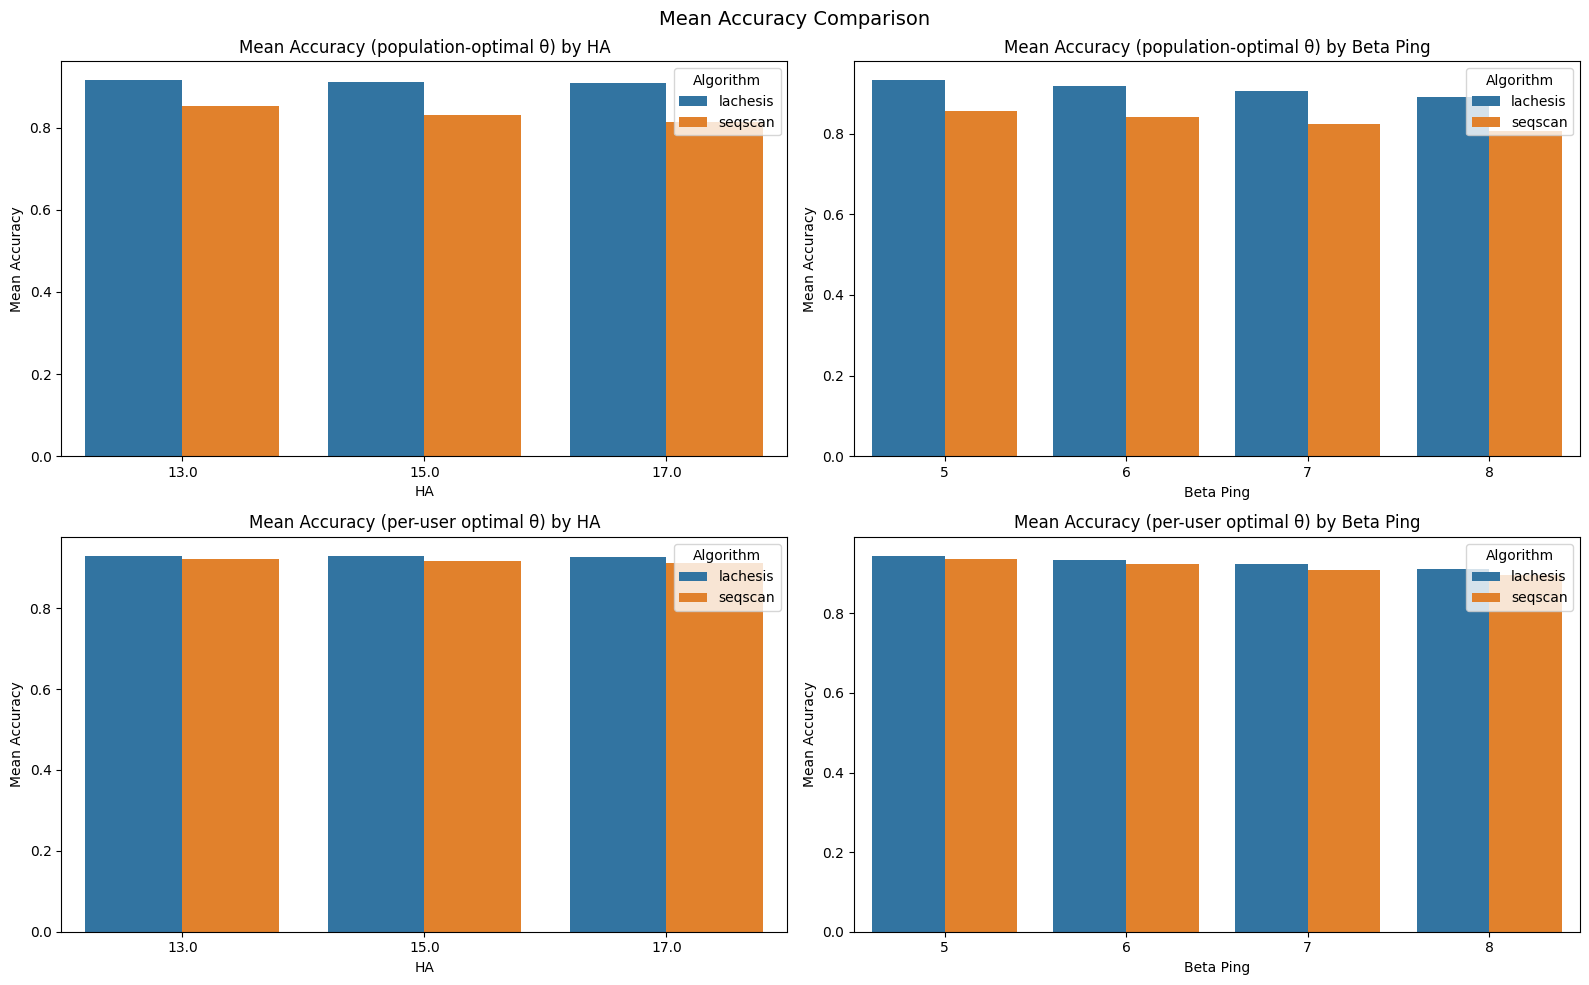

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# ha
sns.barplot(data=final_results, x='ha', y='mean_acc_theta_star',
            hue='algorithm', errorbar=None, ax=ax1)
ax1.set_xlabel('HA')
ax1.set_ylabel('Mean Accuracy')
ax1.set_title('Mean Accuracy (population-optimal θ) by HA')
ax1.legend(title='Algorithm')

sns.barplot(data=final_results, x='ha', y='mean_acc_theta_star_i',
            hue='algorithm', errorbar=None, ax=ax3)
ax3.set_xlabel('HA')
ax3.set_ylabel('Mean Accuracy')
ax3.set_title('Mean Accuracy (per-user optimal θ) by HA')
ax3.legend(title='Algorithm')

# beta_ping
sns.barplot(data=final_results, x='beta_ping', y='mean_acc_theta_star',
            hue='algorithm', errorbar=None, ax=ax2)
ax2.set_xlabel('Beta Ping')
ax2.set_ylabel('Mean Accuracy')
ax2.set_title('Mean Accuracy (population-optimal θ) by Beta Ping')
ax2.legend(title='Algorithm')

sns.barplot(data=final_results, x='beta_ping', y='mean_acc_theta_star_i',
            hue='algorithm', errorbar=None, ax=ax4)
ax4.set_xlabel('Beta Ping')
ax4.set_ylabel('Mean Accuracy')
ax4.set_title('Mean Accuracy (per-user optimal θ) by Beta Ping')
ax4.legend(title='Algorithm')

plt.suptitle('Mean Accuracy Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
final_results['ha_beta'] = final_results.apply(
    lambda row: f"ha={int(row['ha'])} \n β={int(row['beta_ping'])}", axis=1
)

In [55]:
final_results

,algorithm,ha,beta_ping,mean_acc_theta_star,mean_acc_theta_star_i,std_acc_theta_star,theta_star,min_pts,ha_beta
0,lachesis,13.0,5,0.936536,0.9465,0.032100,61.258621,NaN,ha=13 \n β=5
12,seqscan,13.0,5,0.867290,0.9400,0.151429,17.235294,2.0,ha=13 \n β=5
4,lachesis,15.0,5,0.932866,0.9449,0.034322,65.655172,NaN,ha=15 \n β=5
16,seqscan,15.0,5,0.855535,0.9359,0.154955,17.235294,2.0,ha=15 \n β=5
8,lachesis,17.0,5,0.928560,0.9435,0.037488,70.051724,NaN,ha=17 \n β=5
20,seqscan,17.0,5,0.843624,0.9310,0.155881,17.235294,2.0,ha=17 \n β=5
1,lachesis,13.0,6,0.919687,0.9355,0.039479,56.862069,NaN,ha=13 \n β=6
13,seqscan,13.0,6,0.866464,0.9278,0.128124,17.235294,2.0,ha=13 \n β=6
5,lachesis,15.0,6,0.915482,0.9341,0.043376,61.258621,NaN,ha=15 \n β=6
17,seqscan,15.0,6,0.834537,0.9244,0.162770,19.264706,2.0,ha=15 \n β=6


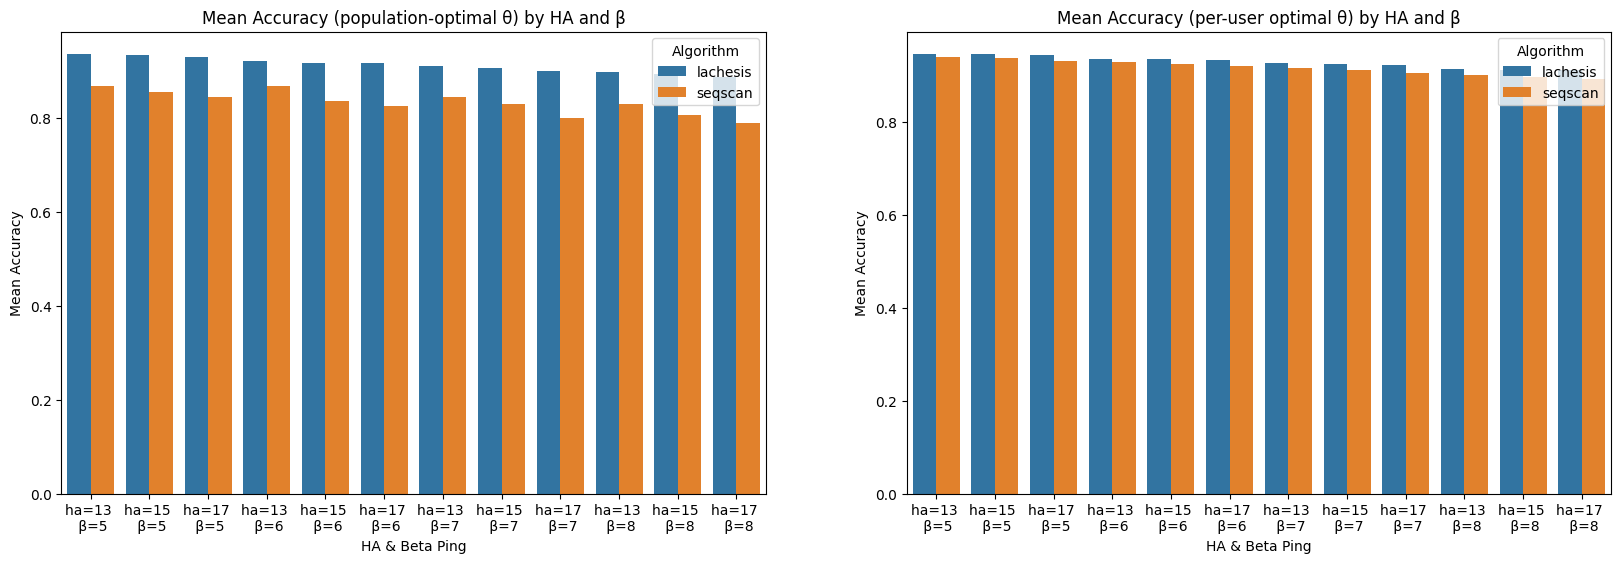

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
ax1, ax2 = axes.flatten()

sns.barplot(data=final_results, x='ha_beta', y='mean_acc_theta_star',
            hue='algorithm', errorbar=None, ax=ax1)
ax1.set_xlabel('HA & Beta Ping')
ax1.set_ylabel('Mean Accuracy')
ax1.set_title('Mean Accuracy (population-optimal θ) by HA and β')
ax1.legend(title='Algorithm')

sns.barplot(data=final_results, x='ha_beta', y='mean_acc_theta_star_i',
            hue='algorithm', errorbar=None, ax=ax2)
ax2.set_xlabel('HA & Beta Ping')
ax2.set_ylabel('Mean Accuracy')
ax2.set_title('Mean Accuracy (per-user optimal θ) by HA and β')
ax2.legend(title='Algorithm')

plt.show()

In [57]:
final_results['gap'] = final_results['mean_acc_theta_star_i'] - final_results['mean_acc_theta_star']

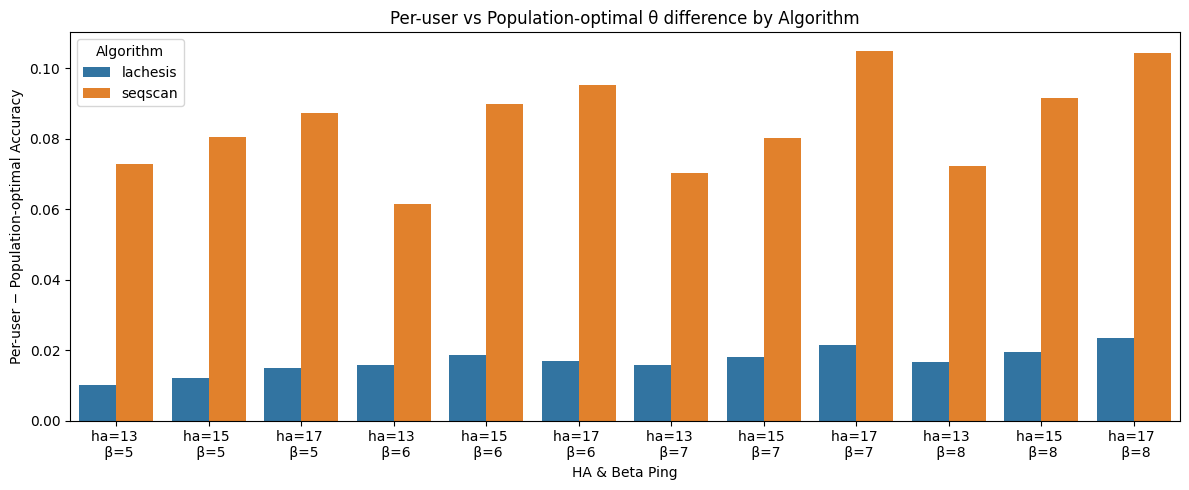

In [62]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=final_results,
    x='ha_beta',
    y='gap',
    hue='algorithm',
    errorbar=None,
    ax=ax
)

ax.set_xlabel('HA & Beta Ping')
ax.set_ylabel('Per-user − Population-optimal Accuracy')
ax.set_title('Per-user vs Population-optimal θ difference by Algorithm')
ax.tick_params(axis='x')
ax.legend(title='Algorithm')

plt.tight_layout()
plt.show()